In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import math
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = np.array(iris.data)
y = iris.target 

In [3]:
X.shape

(150, 4)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# 1st methood 
# K = ("Odd", "Even")[ math.floor(np.sqrt(X_train.shape[0]) ) % 2 == 0 ]
# K
k = (lambda x: x+1 if x %2 == 0 else x)(math.floor(np.sqrt(X_train.shape[0])))
k

11

In [6]:
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [7]:
predictions = knn.predict(X_test)


In [8]:
accuracy_score(y_test, predictions)

1.0

In [9]:
confusion_matrix(y_test, predictions)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [10]:
X_train.shape

(120, 4)

In [11]:
# 2nd methood 
accuracy = []

for i in range(1, 120):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    accuracy.append(accuracy_score(y_test, knn.predict(X_test)))

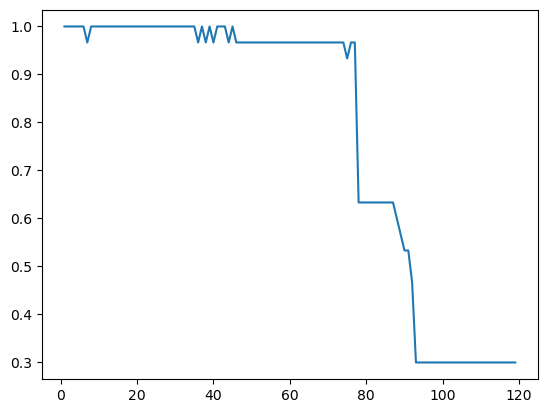

In [12]:
plt.plot(range(1, 120 ), accuracy)

In [26]:
error_train=[]
error_test=[]

for i in range(1,120):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    x=confusion_matrix(y_train,knn.predict(X_train))
    y=confusion_matrix(y_test,knn.predict(X_test))
    error_train.append((x[0][1]+x[0][2]+x[1][0]+x[1][2]+x[2][0]+x[2][1])/x.sum())
    error_test.append((x[0][1]+x[0][2]+x[1][0]+x[1][2]+x[2][0]+x[2][1])/y.sum())

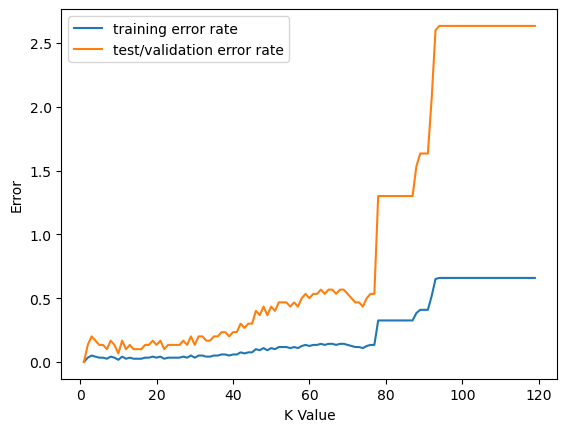

In [27]:
plt.plot(range(1,120),error_train,label='training error rate')
plt.plot(range(1,120),error_test,label='test/validation error rate')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.legend()